<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# <font color=18453B>CMSE 801 - Day 15</font>
## Continuing to fit models to data, thoughtfully
### October 23, 2024

## General Course Announcements

* Quiz 3 will take place on Monday, **October 28**, during the last 30 minutes of class.
    - This will involves concepts and topics from Homework 3.
* Homework 3 is due this Friday, **October 25**.
* The **Project Proposal** is due by 11:59pm Sunday, **October 27**, as part of the Day 16 PCA.

## Semester Project

* The semester project details are on the website.
    * This includes a grading rubric and a full set of expectations for what you will turn in.
* As you start working on your project, if you find it helpful, there is a **Project Template Notebook**, which is meant to provide one possible idea for how you might structure your final project notebook.

## Questions/comments from Day 15 PCA

* How do you know what model to use to fit your data?
* Some questions about using and comments about getting comfortable with curve_fit
* Is seems like the order of the arguments in my function is important when using curve_fit, why is that?
* How do I use the best fit parameters to make my "expected" model values?

#### Since it's been a minute, we'll review our `curve_fit` example from last time again.


### Let's try a model of the following form:

### $$ F(x) =  a e^{-bx} + c $$

In [1]:
# Let's get all of our importants out of the way first!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# We need to define our function
# The independent variable _must be first_ and then the model parameters
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

### Let's generate a bit of data we can try to fit our model to

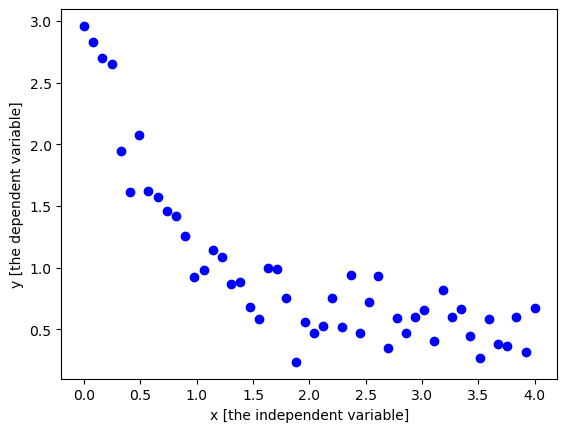

In [3]:
xdata = np.linspace(0, 4, 50)
y = exp_func(xdata, 2.5, 1.3, 0.5)
rng = np.random.default_rng()
y_noise = 0.2 * rng.normal(size=xdata.size)
ydata = y + y_noise
plt.scatter(xdata, ydata, color='b', label='data')
plt.xlabel("x [the independent variable]")
plt.ylabel("y [the dependent variable]");

### Ok, now we have a model and some data, let's use curve_fit!

Best fit parameters: [2.59904619 1.4188295  0.50536944]


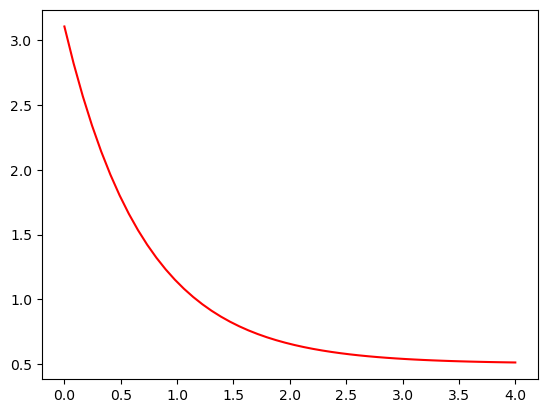

In [4]:
popt, pcov = curve_fit(exp_func, xdata, ydata)
print("Best fit parameters:",popt)
plt.plot(xdata, exp_func(xdata, popt[0], popt[1], popt[2]), color='r',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % (popt[0], popt[1], popt[2]));

Best fit parameters: [2.59904619 1.4188295  0.50536944]


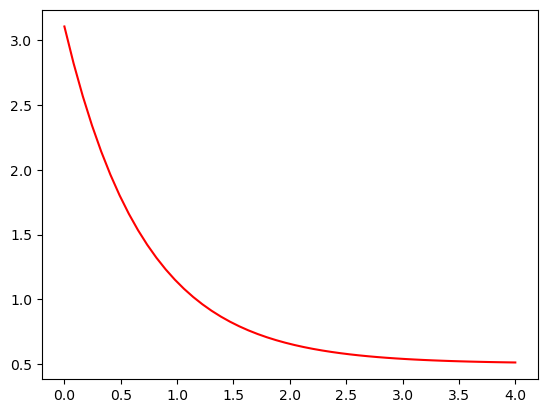

In [5]:
## I could have been more explicit about what I was doing with the best fit parameters
popt, pcov = curve_fit(exp_func, xdata, ydata)
print("Best fit parameters:",popt)
a_fit = popt[0]
b_fit = popt[1]
c_fit = popt[2]
plt.plot(xdata, exp_func(xdata, a_fit, b_fit, c_fit), color='r',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % (a_fit, b_fit, c_fit));

### How does our model look compared to the data?

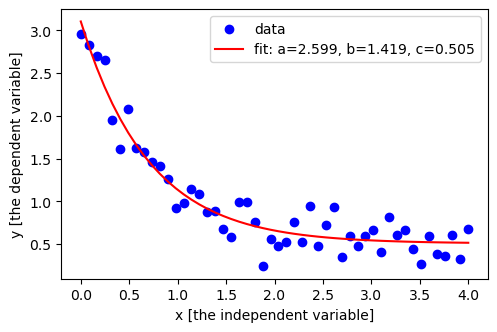

In [6]:
plt.figure(figsize=(5.5,3.5))
plt.scatter(xdata, ydata, color='b', label='data')
plt.xlabel("x [the independent variable]")
plt.ylabel("y [the dependent variable]")
plt.plot(xdata, exp_func(xdata, popt[0], popt[1], popt[2]), color='r',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % (popt[0], popt[1], popt[2]))
plt.legend();

### But how is all of this working? 

### Quick note about regression

* "**Regression**" is a stastical method that can be used to determine the relationship between a dependent variable and one or more independent, or explanatory variable(s). This is a version of "**supervised**" machine learning.
    * "*Simple Linear regression*" is when we fit a line between just two variables using a model of the form $y = mx + b$ where $y$ is the dependent variable and $x$ is the independent variable.
        * $m$ is the slope of the line, sometimes referred to as the "regression coefficient".
        * $b$ is just a constant that shifts the line up or down on the dependent variable axis.
    * Multiple linear regression is when two or more independent variables are used to predict the dependent (response) variable (which results in finding a surface of best fit).

### For fitting a line, we're using a "least squares" approach to define the best fit parameters.

Let's look back at some of the equations that were used for the "Ordinary Least Squares" (OLS) regression:

$$\bar{x} = \frac{1}{N}\sum_i x_i$$

$$\bar{y} = \frac{1}{N}\sum_i y_i$$

$$ m = \frac{\sum_i x_i y_i - N\bar{x}\bar{y}}{\sum_i x_i^2 - N\bar{x}^2}$$

$$ b = \bar{y} - m\bar{x}$$

This might also be a useful resource for helping to think about the "ordinary least squares" appproach: https://setosa.io/ev/ordinary-least-squares-regression/

## Goals for today
* Practice using curve_fit to fit a model to day -- specifically, revisiting the population model! (which you fit, "by eye" in the homework)
* Use your results to predict/forecast expected values, but within the bounds of the data and beyond (e.g. extrapolation)
* Determine if/how we need to update our model in the face of new data

## Looking forward - Day 16 PCA: Best practices in Data Visualization

* Spend some time thinking about what it means to make effective data visualization. This will be important for your project!